In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo

wine_quality = fetch_ucirepo(id=186)

X = wine_quality.data.features
y = wine_quality.data.targets

# Initial Inspection

In [4]:
df = pd.concat([X, y], axis=1)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [6]:
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


In [7]:
df.shape

(6497, 12)

In [8]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# Exploratory Data Analysis

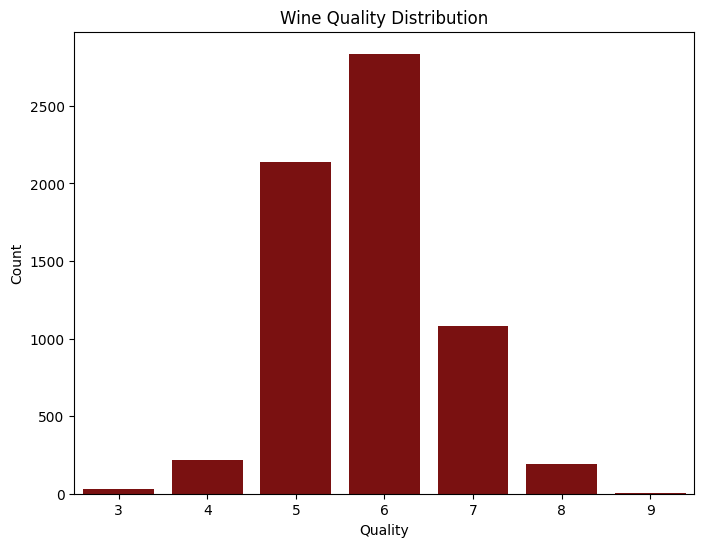

In [9]:
#quality distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='quality', color='darkred')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

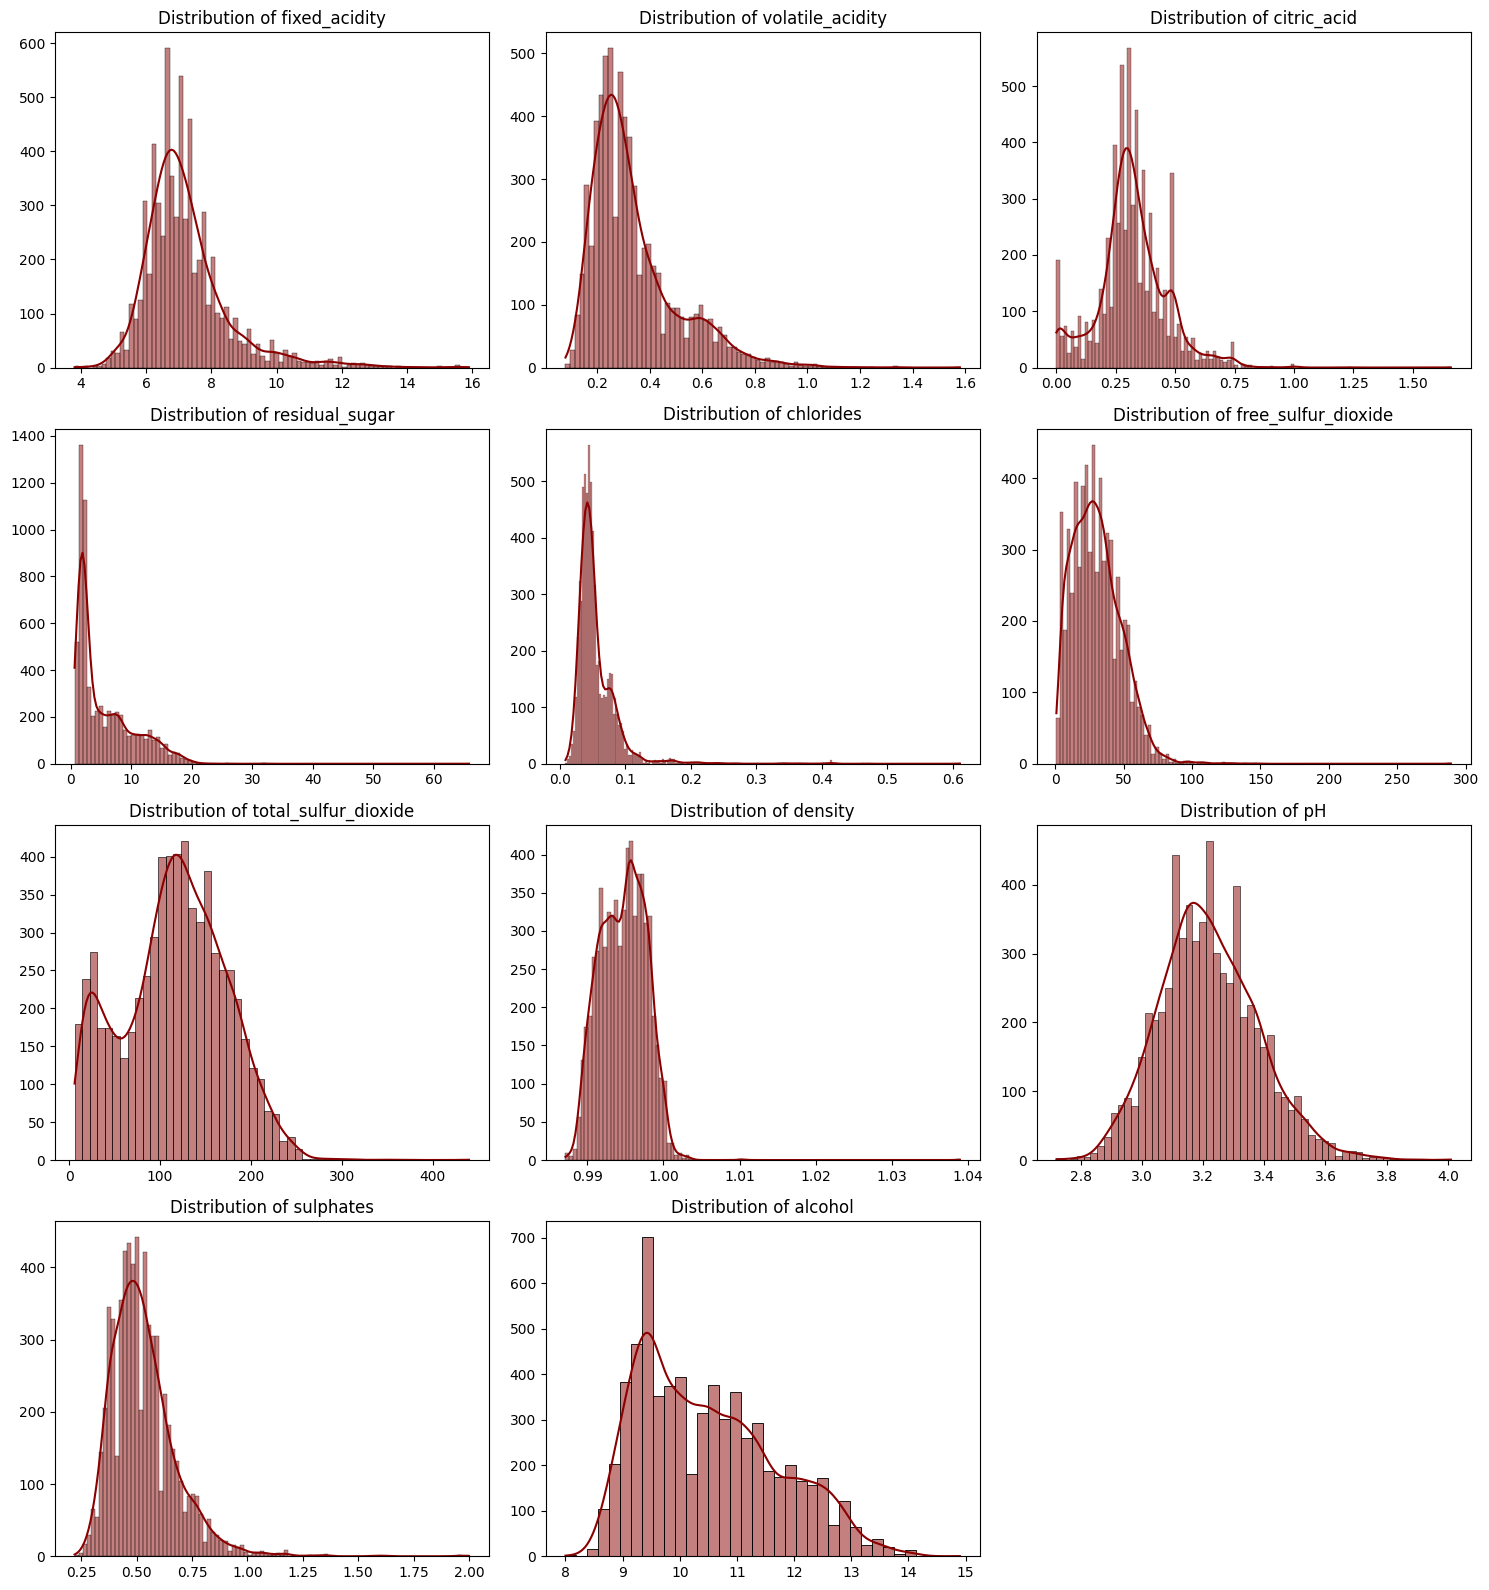

In [10]:
columns = df.drop(columns = 'quality').columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkred')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

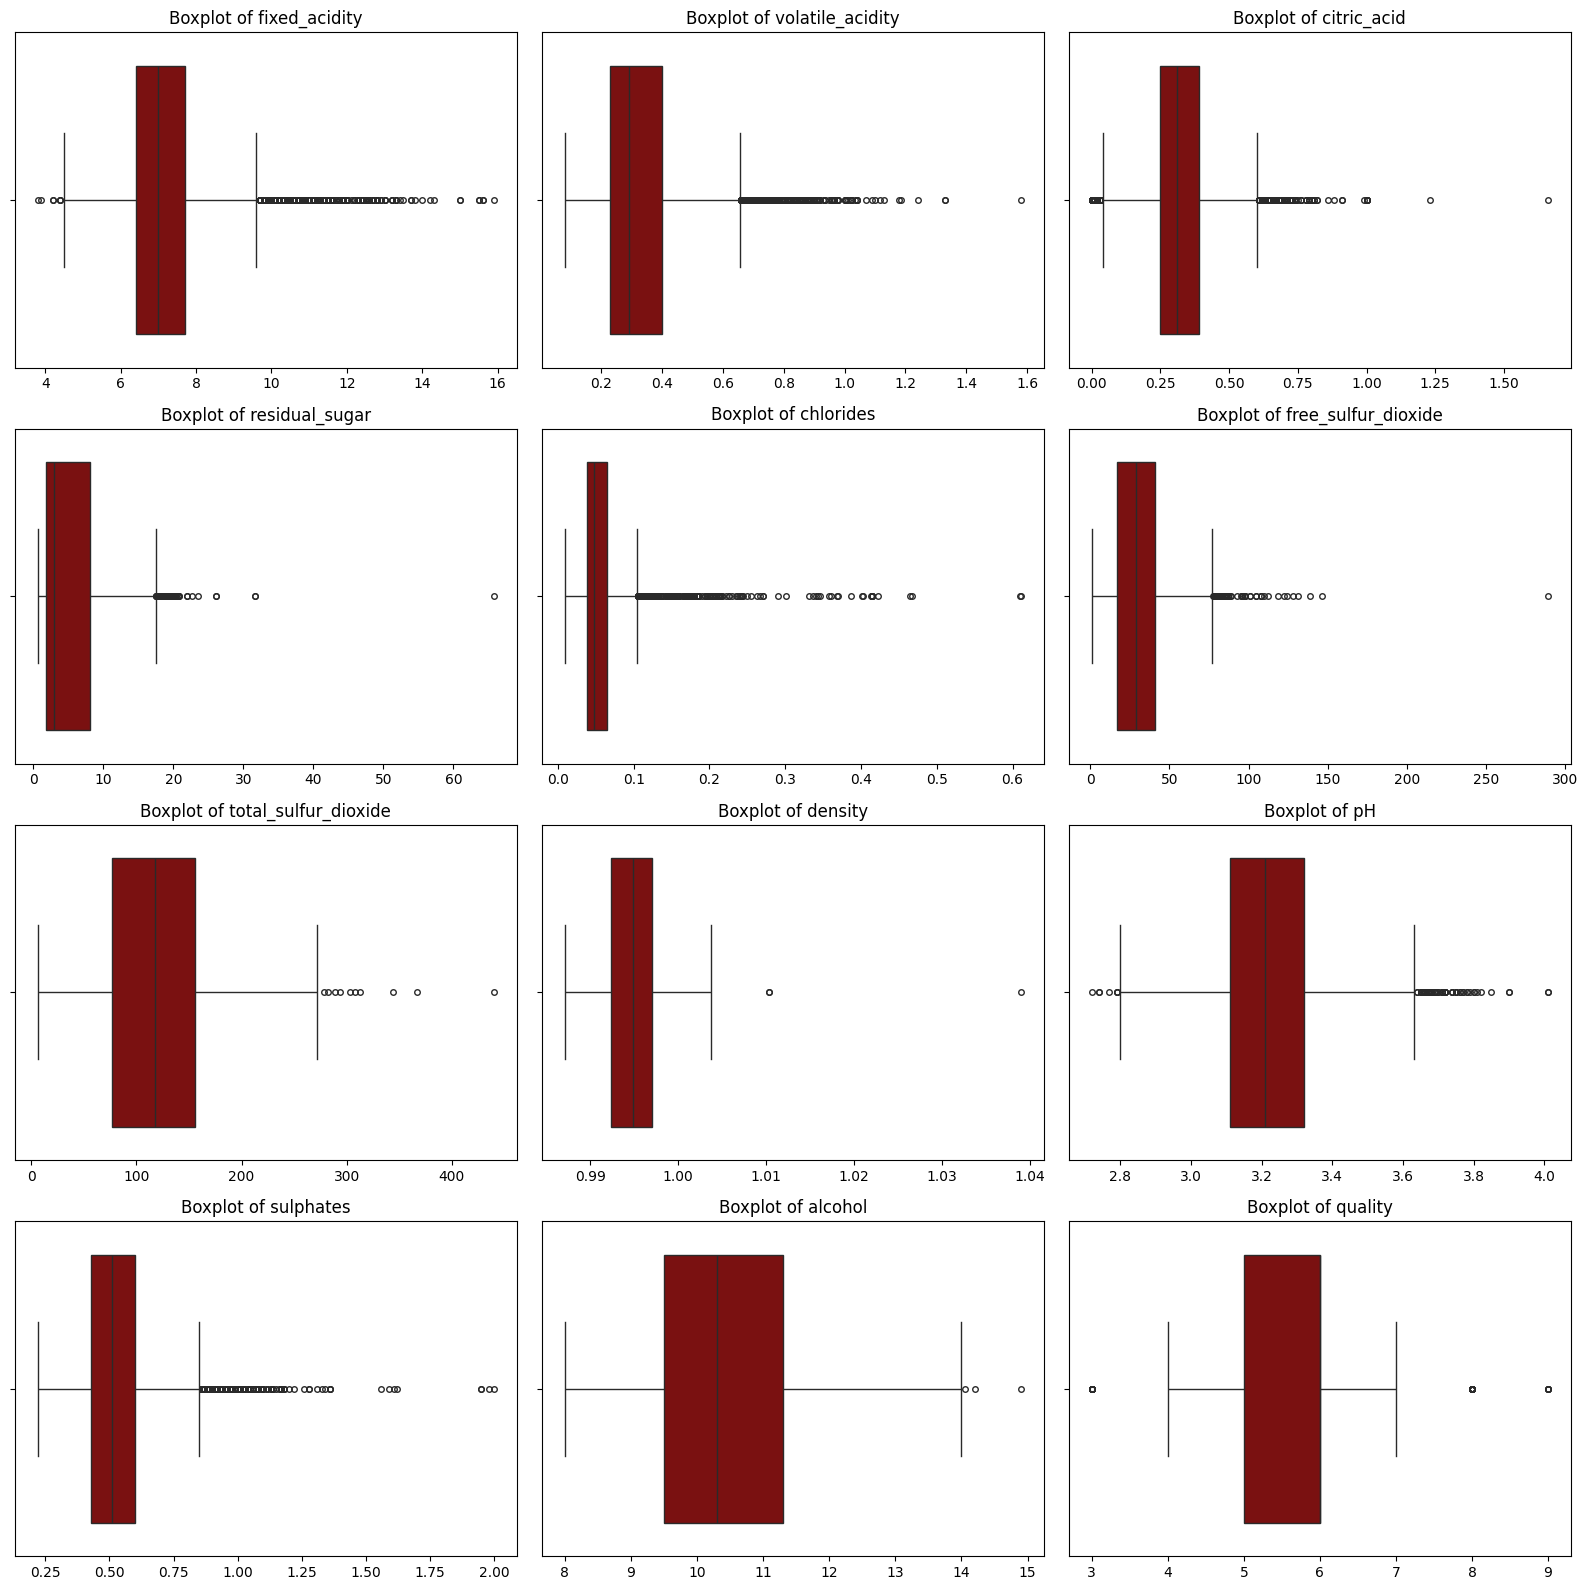

In [11]:
columns = df.columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i], color='darkred', fliersize=4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

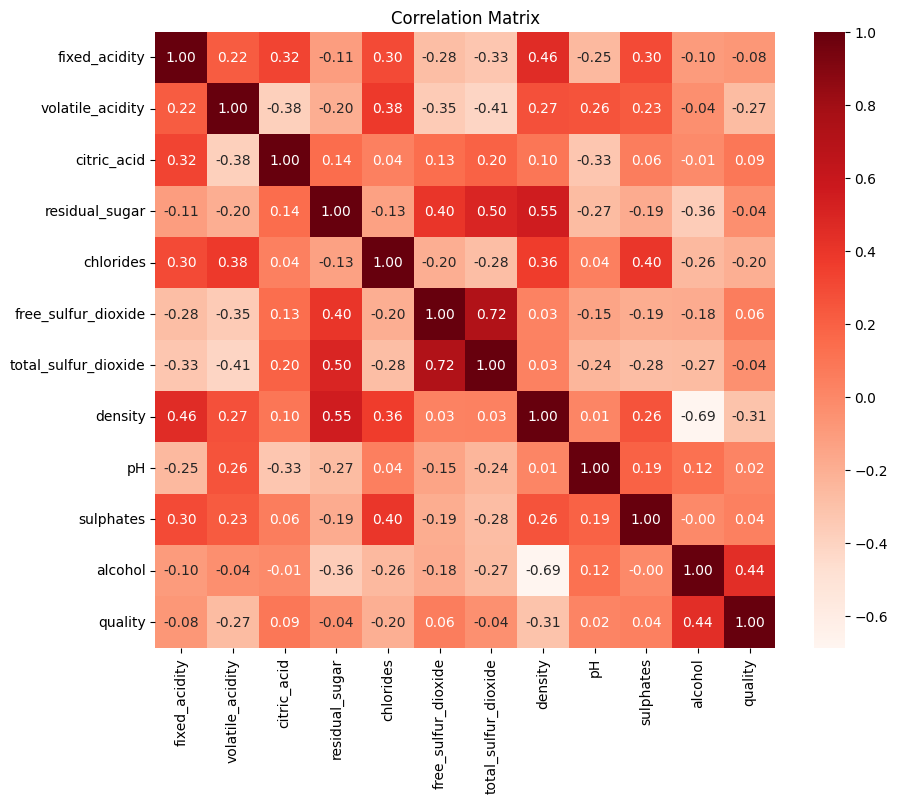

In [12]:
#corr matrix
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

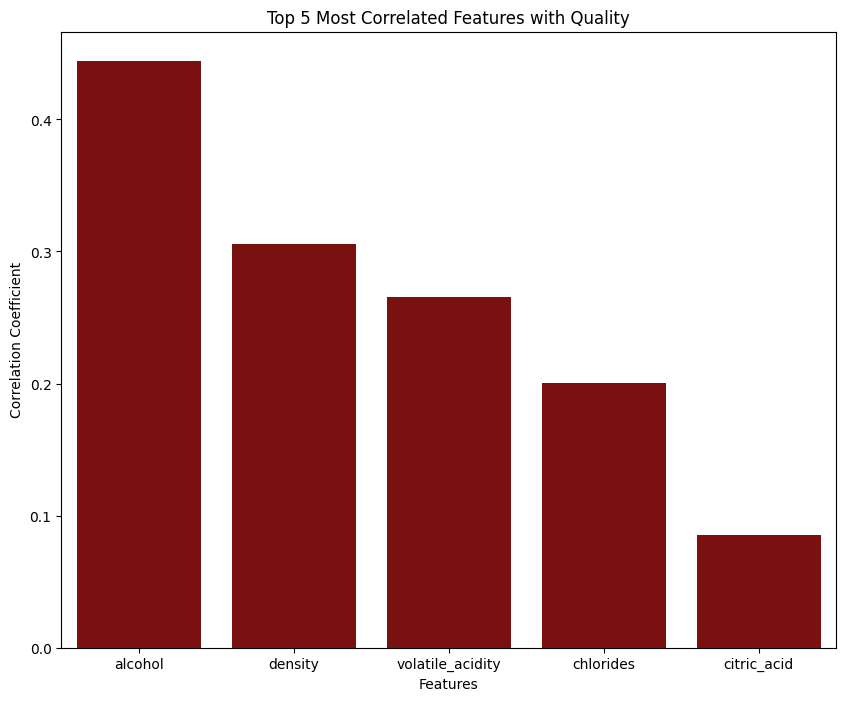

In [13]:
# barplot of 5 features most correlated with quality
corr_features = corr_matrix['quality'].abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_features.index[1:6], y=corr_features.values[1:6], color='darkred')
plt.title('Top 5 Most Correlated Features with Quality')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.show()

<Figure size 1000x800 with 0 Axes>

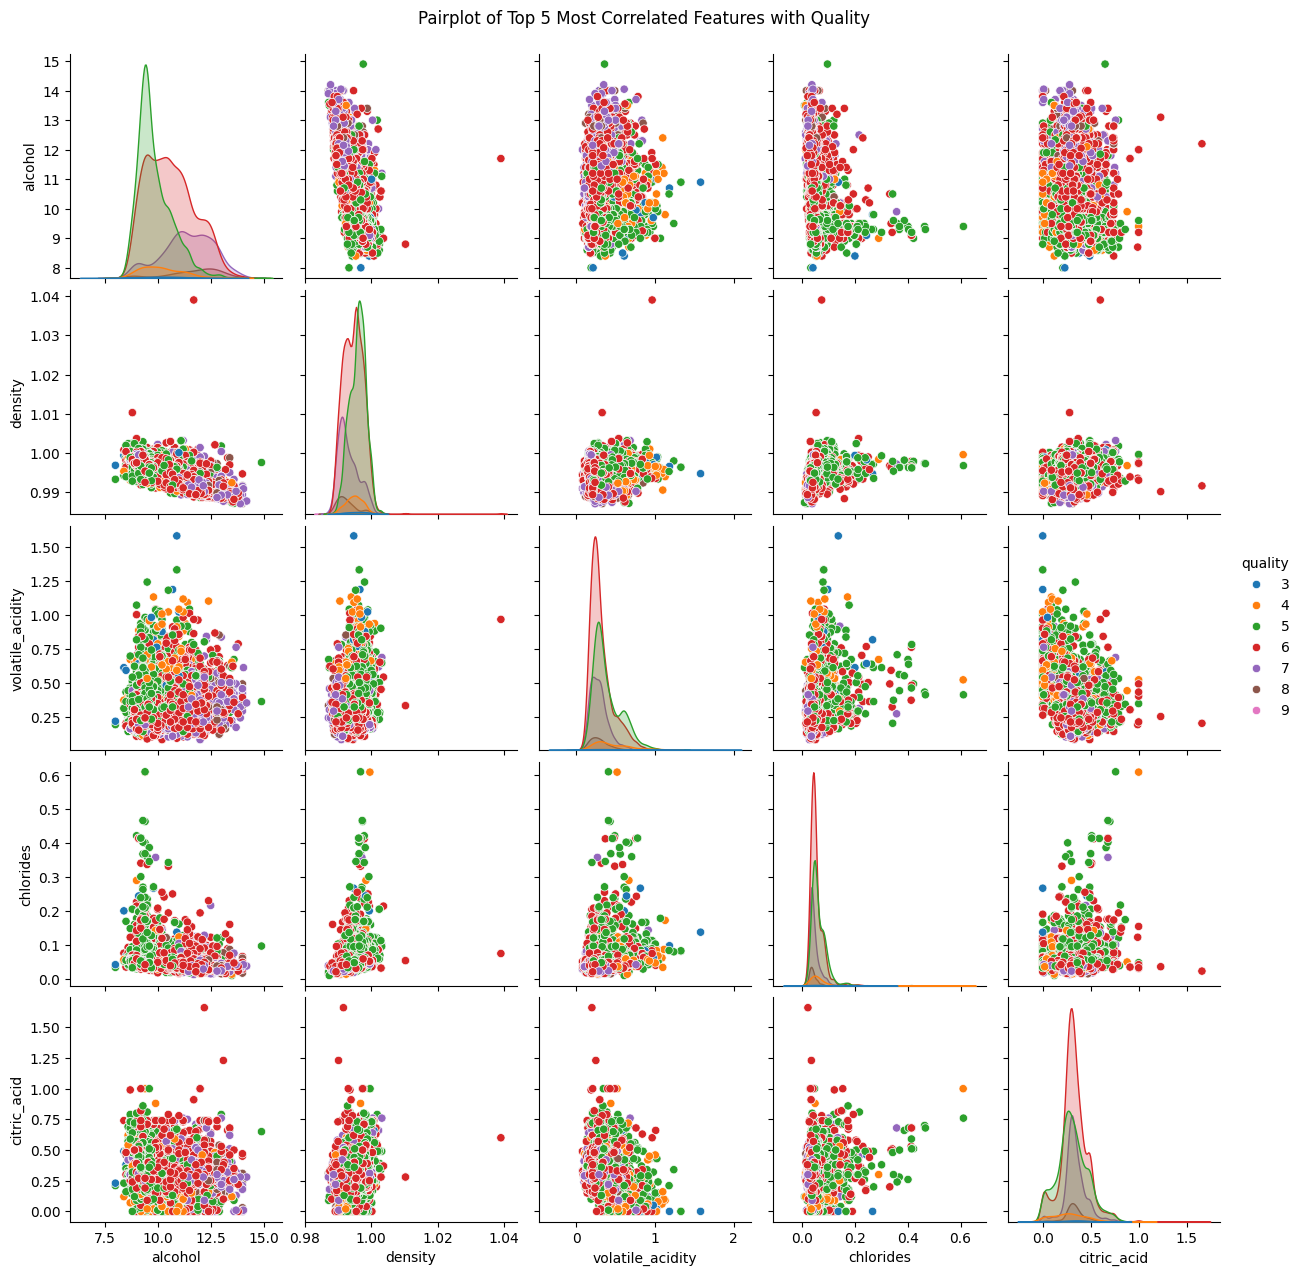

In [14]:
top_5_features = df.corr()['quality'].abs().sort_values(ascending=False).iloc[1:6].index.tolist()
plot_features = top_5_features + ['quality']
plt.figure(figsize=(10, 8))
sns.pairplot(df[plot_features], hue='quality', palette='tab10')
plt.suptitle('Pairplot of Top 5 Most Correlated Features with Quality', y=1.02)
plt.show()

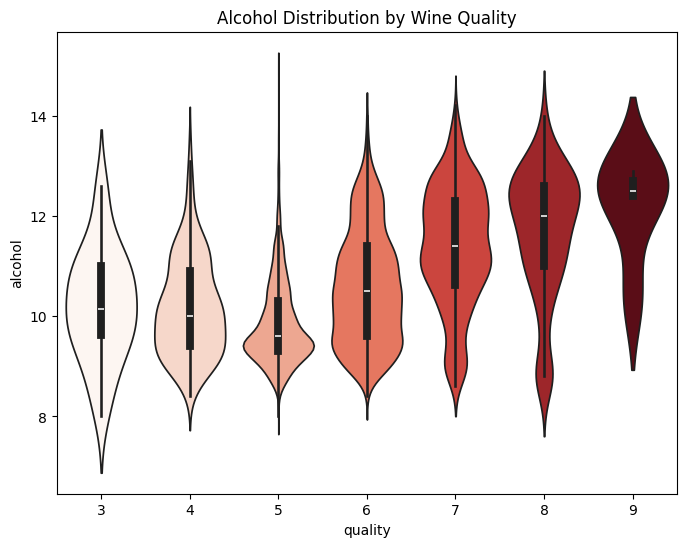

In [15]:
# Przykład dla alkoholu - najczęstszego "predyktora" jakości
plt.figure(figsize=(8, 6))
sns.violinplot(x='quality', y='alcohol', data=df, hue='quality', palette='Reds', legend=None)
plt.title('Alcohol Distribution by Wine Quality')
plt.show()

# Data Cleaning and Preprocessing

In [16]:
# Removing extreme quality ratings due to insufficient data points for reliable model training
df = df[df['quality'].isin([4, 5, 6, 7, 8])]

In [18]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [27]:
def remove_outliers_iqr(df, columns):
    mask = pd.Series(True, index=df.index)

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = mask & (df[col] >= lower_bound) & (df[col] <= upper_bound)

    return df[mask]

cols_to_clean = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
                 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'sulphates']

df_clean = remove_outliers_iqr(df, cols_to_clean)

print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} rows")


Rows before: 6462
Rows after: 5048
Removed: 1414 rows


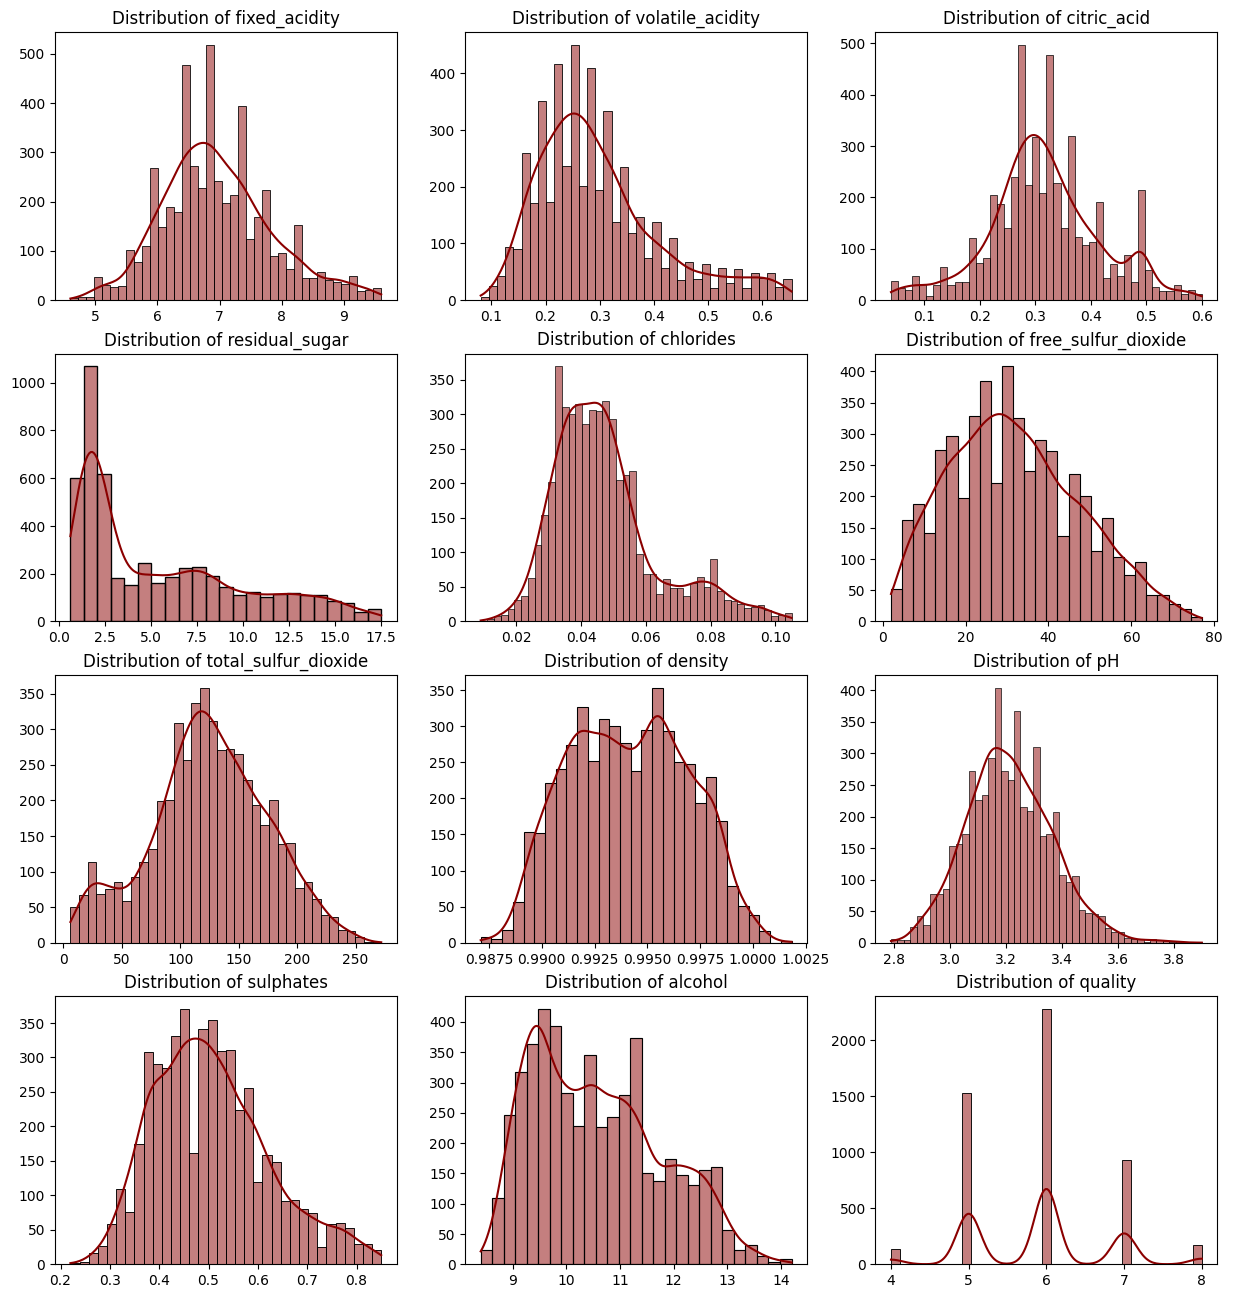

In [29]:
columns = df.columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='darkred')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


plt.show()

In [56]:
X=df_clean.drop('quality', axis=1)
y=df_clean['quality'].astype(int)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building and Evaluation

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [60]:
def evaluate_model(y_train, y_pred_train, y_test, y_pred_test, model_name):
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_pred_train)

    print(f"--- {model_name} Train Performance ---")
    print(f"MAE: {mae_train:.4f}")
    print(f"RMSE: {rmse_train:.4f}")
    print(f"R2 Score: {r2_train:.4f}")

    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\n--- {model_name} Test Performance ---")
    print(f"MAE: {mae_test:.4f}")
    print(f"RMSE: {rmse_test:.4f}")
    print(f"R2 Score: {r2_test:.4f}")

In [61]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)
y_pred_test = lr_model.predict(X_test_scaled)
y_pred_train = lr_model.predict(X_train_scaled)

evaluate_model(y_train, y_pred_train, y_test, y_pred_test, "Linear Regression")

--- Linear Regression Train Performance ---
MAE: 0.5627
RMSE: 0.7204
R2 Score: 0.2839

--- Linear Regression Test Performance ---
MAE: 0.5599
RMSE: 0.7137
R2 Score: 0.2793


In [100]:
dt_model = dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)

dt_model.fit(X_train_scaled, y_train)
y_pred_test = dt_model.predict(X_test_scaled)
y_pred_train = dt_model.predict(X_train_scaled)

evaluate_model(y_train, y_pred_train, y_test, y_pred_test, "Decision Tree")

--- Decision Tree Train Performance ---
MAE: 0.5888
RMSE: 0.7200
R2 Score: 0.2846

--- Decision Tree Test Performance ---
MAE: 0.5962
RMSE: 0.7339
R2 Score: 0.2379


In [98]:
gb_model = GradientBoostingRegressor(n_estimators=40, learning_rate=0.07, max_depth=4, subsample=0.4, random_state=42)

gb_model.fit(X_train_scaled, y_train)
y_pred_test = gb_model.predict(X_test_scaled)
y_pred_train = gb_model.predict(X_train_scaled)

evaluate_model(y_train, y_pred_train, y_test, y_pred_test, "Gradient Boosting")

--- Gradient Boosting Train Performance ---
MAE: 0.5080
RMSE: 0.6345
R2 Score: 0.4444

--- Gradient Boosting Test Performance ---
MAE: 0.5338
RMSE: 0.6697
R2 Score: 0.3654
